In [1]:
#Downloading Dataset
import os
import getpass
os.environ["KAGGLE_USERNAME"] = input("Username: ")
os.environ["KAGGLE_KEY"] = getpass.getpass("API Key: ")
!pip install -q kaggle
from kaggle.api.kaggle_api_extended import KaggleApi
kaggle = KaggleApi()
kaggle.authenticate()
dataset = "johnsmith88/heart-disease-dataset"
kaggle.dataset_download_files(
    dataset=dataset,
    path="./",
    unzip=True
)
print("Dataset download is successful.")

Username: varun22
API Key: ··········
Dataset URL: https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset
Dataset download is successful.


In [2]:
#Importing Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score

import joblib

In [3]:
#Task1
df = pd.read_csv("heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [5]:
#Task1
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None


In [10]:
#Task1
print(df.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')


In [11]:
#Task1
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [12]:
#Task1
X = df.drop("target", axis=1)
y = df["target"]

In [14]:
#Task1
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42
)

In [15]:
#Task2
model = RandomForestClassifier(

    n_estimators=200,

    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [16]:
#Task2
pred = model.predict(X_test)

In [17]:
#Task2
accuracy = accuracy_score(y_test, pred)

print("Accuracy:", accuracy)

Accuracy: 0.9853658536585366


In [18]:
#Task2
joblib.dump(model, "model.pkl")

['model.pkl']

In [19]:
#Task2
from google.colab import files
files.download("model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

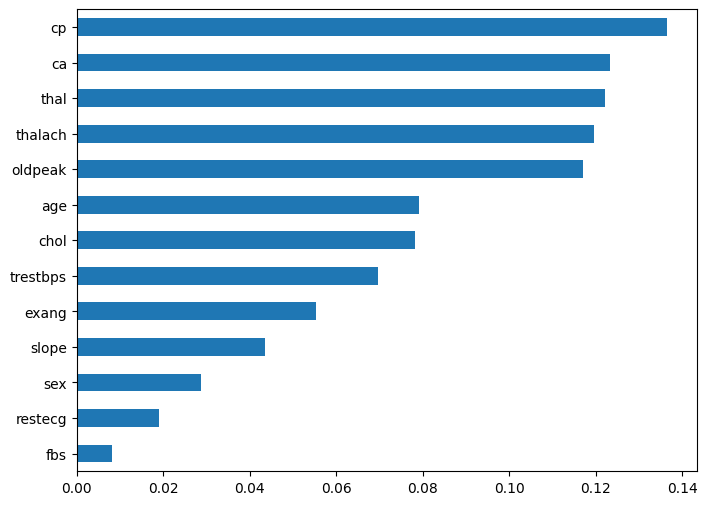

In [20]:
#FeatureImportance
importance = pd.Series(model.feature_importances_, index=X.columns)

importance.sort_values().plot(kind="barh", figsize=(8,6))

plt.show()

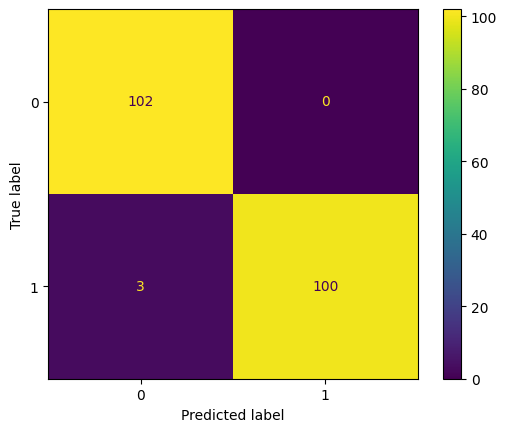

In [21]:
#ConfusionMatrix
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, pred)

plt.show()

In [22]:
#ClassificationReport
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205

